In [1]:
import sys
import os 
sys.path.append(os.path.abspath("../src"))
%load_ext autoreload
%autoreload 2
# from load_data import load_images, images_pil_to_cv, get_image_dimensions, load_image_pair
# from preprocess import resize_image, equalize_histogram, normalize_image, denoise_image, gamma_correction
# from feature_extraction import extract_sift_features, extract_orb_features, draw_keypoints, filter_features_by_response
# from feature_matching import match_features_flann, match_features_bf, draw_matches, extract_matched_points, filter_matches_by_distance
# from geometry import (
#     compute_essential_matrix,
#     recover_pose_from_essential,
#     create_projection_matrix,
#     triangulate_points,
#     filter_by_cheirality,
#     filter_by_depth
# )
from reconstruction import compute_intrinsic_matrix, reconstruct_two_view
from visualization import plot_3d_points, plot_2d_projections, plot_matches, plot_keypoints, plot_image_pair, save_ply


number of images loaded:  18
size of single image: (960, 1280)
TWO-VIEW RECONSTRUCTION PIPELINE (Phase 1)

[1/10] Loading images...
    Image size: 960 x 1280

[2/10] Creating intrinsic matrix...
    K =
[[960.   0. 480.]
 [  0. 960. 640.]
 [  0.   0.   1.]]

[3/10] Extracting SIFT features...
Detected 3723 SIFT features
Detected 3719 SIFT features

[4/10] Matching features (FLANN + ratio test)...
FLANN: Found 1153 good matches

[5/10] Extracting matched points...
    Extracted 1153 point pairs

[6/10] Computing Essential Matrix...
    Essential matrix computed (1059 inliers / 1153 points)
    Inliers: 1059 / 1153

[7/10] Recovering camera pose (R, t)...
    Pose recovered (1042 points in front of both cameras)

[8/10] Building projection matrices...

[9/10] Triangulating 3D points...
    Triangulated 1042 points

[10/10] Filtering points...
    Cheirality filter: kept 1042, removed 0
    Depth filter [0.1, 500]: kept 1042, removed 0
    Reprojection filter (threshold=2.0px): kept 1042

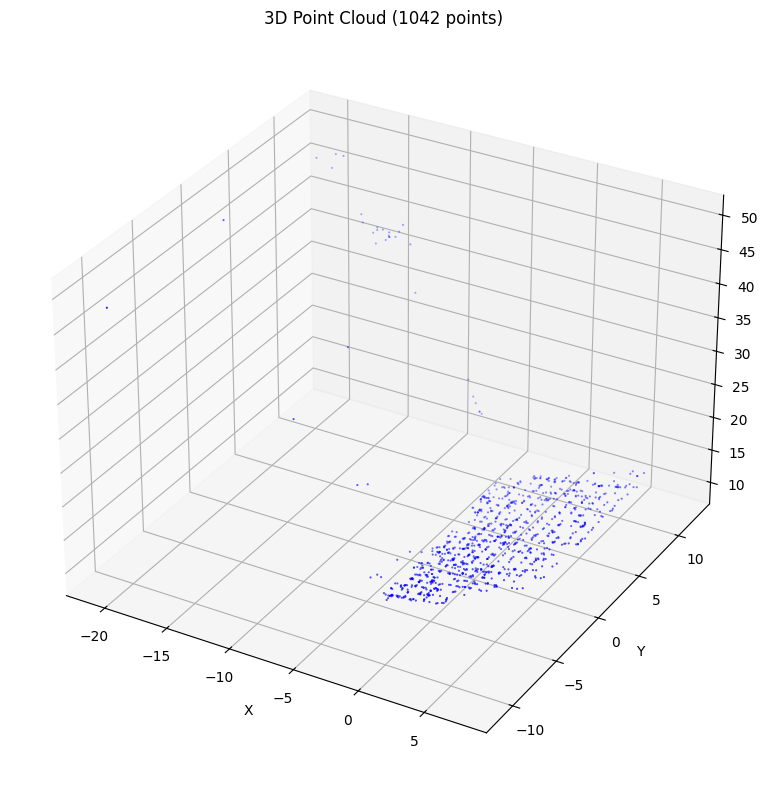

In [2]:
import os
from PIL import Image
path = r"C:\Users\altaf\OneDrive\Desktop\cv pics"
images = []
image_paths = []
count = 0
for filename in sorted(os.listdir(path)):
    if filename.endswith('.jpg'):
        count = count + 1
        img_path = os.path.join(path, filename)
        img = Image.open(img_path)
        images.append(img)
        image_paths.append(img_path)
print("number of images loaded: ", count)
print("size of single image:", images[0].size)
img_idx_1 = 0
img_idx_2 = 11
points_3d, colors, R, t, K, pts1, pts2 = reconstruct_two_view(
    image_paths[img_idx_1],
    image_paths[img_idx_2],
    output_ply='week2_reconstruction.ply'
)

print(f"\nFinal result: {len(points_3d)} points")

if len(points_3d) > 0:
    from visualization import plot_3d_points
    plot_3d_points(points_3d)
